<a href="https://colab.research.google.com/github/saki0901/saket_01/blob/master/GenAI_level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Assignment 1: Predict employee productivity scores***

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create dataset
data = {
    'Experience':[2,5,1,8,4,10,3,6,7,2],
    'Training':[40,60,20,80,50,90,30,70,75,25],
    'Working':[38,42,35,45,40,48,37,44,46,36],
    'Projects':[3,6,2,8,5,9,4,7,7,3],
    'Productivity':[62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)

# Features
X = df[['Experience', 'Training', 'Working', 'Projects']]

# Target
y = df['Productivity']

# Train
model = LinearRegression()
model.fit(X, y)

# Coefficients
print("Coefficients = ",model.coef_)

# Intercept
print("Intercept = ",model.intercept_)

Coefficients =  [-0.9638009   0.03800905  0.81900452  4.70135747]
Intercept =  17.425339366515693


# **Which Factor Most Strongly Impacts Productivity?**

*The number of projects has the strongest impact on productivity. Each additional project increases the productivity score by 4.7 points, as coefficient is approx 4.7.*

# **How Does Training Affect Productivity?**

*Training has a positive but relatively small effect on productivity. Increasing training hours slightly improves employee productivity.*

# **Should the Company Increase Training Hours or Working Hours?**

*Training = 0.038*
*Working Hours = 0.819*

*Working hours has much larger impact.*

# **What Happens if Working Hours Increase Beyond Optimal Limits?**

*If working hours exceed optimal limits, employee get exhausted, which could reduce productivity.*
*Working hours beyond optimal limits is a non-linear data, which can't be captured in this linear regression*

# **Can Productivity Ever Decrease with More Experience?**

*Experience = -0.96*
*But in real scenario, more experience increase Productivity*





# **How would you detect overfitting in this model?**

*Overfitting can be detected by evaluating model performance on unseen data using a train-test split or cross-validation. If the model performs well on training data but poorly on test data, it indicates overfitting*

# **Suggest One New Feature to Improve Prediction Accuracy**

Performance rating.
Employee with high performance rating will be more productive

# **Assignment 2: Loan Default**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Dataset
data = {
    'Age':[28,45,35,50,30,42,26,48,38,55],
    'Income':[6.5,12,8,15,7,10,5.5,14,9,16],
    'CreditScore':[720,680,750,640,710,660,730,650,700,620],
    'LoanAmount':[5,10,6,12,5,9,4,11,7,13],
    'LoanTerm':[5,10,7,15,5,10,4,12,8,15],
    'Employment':[0,1,0,1,0,0,0,1,0,1],
    'Loan':[0,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

X = df.drop('Loan', axis=1)
y = df['Loan']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN model
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

prediction = knn.predict(X_test)

print("Prediction:", prediction)
print("Actual:", y_test.values)

Prediction: [0 1]
Actual: [0 1]


# **Identify High-Risk Customers**

In [ ]:
high_risk_customers = df[df['Loan'] == 1]
print(high_risk_customers)


   Age  Income  CreditScore  LoanAmount  LoanTerm  Employment  Loan
1   45    12.0          680          10        10           1     1
3   50    15.0          640          12        15           1     1
5   42    10.0          660           9        10           0     1
7   48    14.0          650          11        12           1     1
9   55    16.0          620          13        15           1     1


*High-risk customers have lower credit scores, higher loan amounts, and longer loan durations.*

# **What Patterns Lead to Loan Default?**

*Loan defaults are more likely among customers with lower credit scores, larger loan amounts, longer loan terms, and self-employment status.*

# **How Do Credit Score and Income Influence Predictions?**

*Higher score --> lower risk*,
*Higher income --> high repayment capacity*

# **Suggest Banking Policies Based on Model Output**

*Banks can introduce credit score thresholds, limit loan amounts compare to income, apply stricter verification for self-employed, and restrict excessively long loan terms.*

# **Compare KNN with Decision Trees**

*KNN predicts based on similarity to neighboring customers, while Decision Trees create interpretable decision rules*

# **What Happens if LoanAmount Dominates Distance Calculation?**

*If LoanAmount dominates the distance calculation, the KNN model will focus mainly on loan size while ignoring other important variables such as credit score or income. Feature scaling is required to ensure balanced influence of all variables.*

# **Should KNN Be Used in Real-Time Loan Approval Systems?**

*If the bank has 1 million customers, KNN must calculate 1 million distances per prediction. This makes it slow for real-time systems.*

# **Assignment 3: Neural Network for fraud detection**

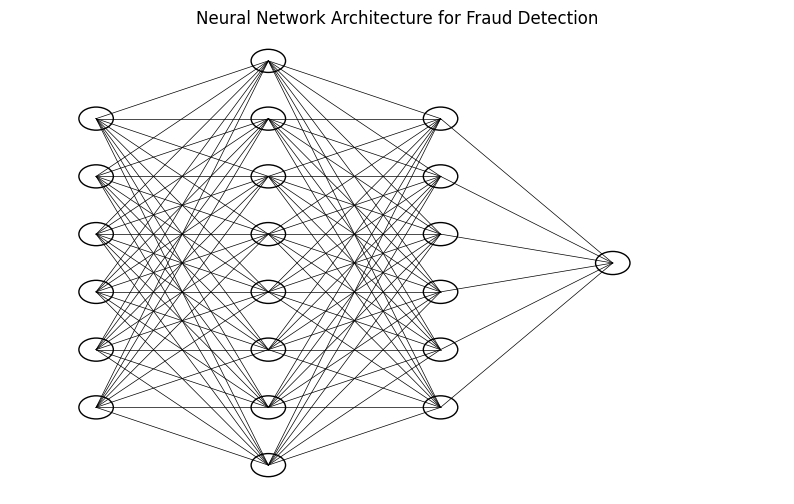

In [ ]:
import matplotlib.pyplot as plt

def draw_neural_network(layers):

    fig, ax = plt.subplots(figsize=(10,6))

    horizontal_spacing = 2
    vertical_spacing = 1

    neuron_positions = []

    # Draw neurons
    for layer_index, neurons in enumerate(layers):

        x = layer_index * horizontal_spacing
        y_positions = []

        for neuron_index in range(neurons):

            y = neuron_index * vertical_spacing - (neurons-1)/2
            circle = plt.Circle((x,y),0.2,fill=False)

            ax.add_patch(circle)
            y_positions.append((x,y))

        neuron_positions.append(y_positions)

    # Draw connections
    for layer_index in range(len(layers)-1):

        for (x1,y1) in neuron_positions[layer_index]:
            for (x2,y2) in neuron_positions[layer_index+1]:

                ax.plot([x1,x2],[y1,y2],'k-',linewidth=0.5)

    ax.set_xlim(-1, len(layers)*horizontal_spacing)
    ax.set_ylim(-4,4)
    ax.axis('off')

    plt.title("Neural Network Architecture for Fraud Detection")
    plt.show()


# Layer configuration
layers = [6,8,6,1]

draw_neural_network(layers)

# **Assignment 4: 3D plot for house price prediction**

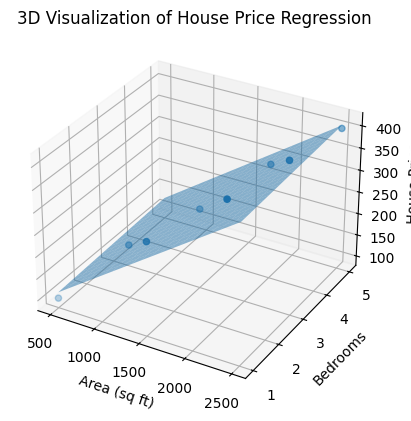

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Sample dataset
area = np.array([500,1000,1200,1500,1800,2000,2200,2500])
bedrooms = np.array([1,2,2,3,3,4,4,5])
price = np.array([100,200,220,260,300,340,360,400])

# Combine features
X = np.column_stack((area, bedrooms))
y = price

# Train regression model
model = LinearRegression()
model.fit(X,y)

# Create meshgrid for surface
area_range = np.linspace(area.min(), area.max(), 20)
bedroom_range = np.linspace(bedrooms.min(), bedrooms.max(), 20)

A,B = np.meshgrid(area_range, bedroom_range)

# Predict price for grid
Z = model.predict(np.column_stack((A.ravel(), B.ravel())))
Z = Z.reshape(A.shape)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data
ax.scatter(area, bedrooms, price)

# Regression surface
ax.plot_surface(A,B,Z,alpha=0.5)

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("House Price")

ax.set_title("3D Visualization of House Price Regression")

plt.show()

# **Assignment 5: “Policy & Claims Copilot” (Customer support + Claims pre-check)**

*Installation of required library*

In [17]:
!pip install langchain openai faiss-cpu pypdf tiktoken langchain_community langchain_openai

In [24]:
!pip install sentence-transformers

*Upload Policy PDF*


In [39]:
from google.colab import files
uploaded = files.upload()

pdf_path = list(uploaded.keys())[0]
print("Uploaded:", pdf_path)

Saving a370272f732749999e7c19e82e38ad7c.pdf to a370272f732749999e7c19e82e38ad7c (1).pdf
Uploaded: a370272f732749999e7c19e82e38ad7c (1).pdf


*Importing required libraries*

In [40]:
import numpy as np
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
import faiss
from transformers import pipeline

In [43]:
# =========================
# 1. LOAD PDF
# =========================
reader = PdfReader(pdf_path)

documents = []
for page in reader.pages:
    text = page.extract_text()
    if text:
        documents.append(text)

print("Pages loaded:", len(documents))


# =========================
# 2. CHUNKING
# =========================
def chunk_text(text, chunk_size=500):
    chunks = []
    for i in range(0, len(text), chunk_size):
        chunks.append(text[i:i+chunk_size])
    return chunks

chunks = []
for doc in documents:
    chunks.extend(chunk_text(doc))

print("Total chunks:", len(chunks))


# =========================
# 3. EMBEDDINGS
# =========================
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = embed_model.encode(chunks)

# =========================
# Convert to numpy
# =========================
embeddings = np.array(embeddings).astype('float32')


# =========================
# 4. FAISS VECTOR DB
# =========================
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

print("FAISS index ready")


# =========================
# 5. LOCAL LLM
# =========================
generator = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    max_length=512
)


# =========================
# 6. RETRIEVAL FUNCTION
# =========================
def retrieve(query, k=3):
    query_vec = embed_model.encode([query]).astype('float32')
    distances, indices = index.search(query_vec, k)

    results = [chunks[i] for i in indices[0]]
    return results


# =========================
# 7. CLAIM PRE-CHECK
# =========================
def claim_precheck(query):
    if "waiting period" in query.lower():
        return "⚠️ Check waiting period clause carefully before claim."
    if "surgery" in query.lower():
        return "⚠️ Ensure procedure is covered under policy."
    return None


# =========================
# 8. CHAT LOOP
# =========================
while True:
    query = input("\nAsk your question (or type 'exit'): ")

    if query.lower() == "exit":
        break

    # Retrieve relevant chunks
    context_chunks = retrieve(query)
    context = "\n\n".join(context_chunks)

    # Prompt
    prompt = f"""
    Answer ONLY from the policy context below.
    If not found, say "Not available in policy".

    Context:
    {context}

    Question:
    {query}
    """

    # Generate answer
    result = generator(prompt)[0]["generated_text"]

    print("\n📌 Answer:\n", result)

    # Claim pre-check
    warning = claim_precheck(query)
    if warning:
        print("\n🧠 Claim Insight:", warning)

Pages loaded: 27
Total chunks: 203


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS index ready


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl


Ask your question (or type 'exit'): Is knee surgery covered?

📌 Answer:
 
    Answer ONLY from the policy context below.
    If not found, say "Not available in policy".

    Context:
    ive condition, Age related osteoarthritis and Osteoporosis unless such joint replacement 
surgery is necessitated by accidental Bodily Injury. 
 
This Exclusion shall apply only to the extent of the amount by which the limit of indemnity has 
been increased if the Policy is a renewal of the Health Insurance Policy with Insurer  without break 
in cover. 
 
If the policy is a renewal / rollover from any Other Insurer   and if the Insured  is covered 
continuously and without interruption/break in 

treatment in a 
Hospital, this exclusion stands waived provided that the Insured  establishes to the Insurer’s  
satisfaction that Insured Person  was unaware of and had not taken any advice or medication for 
such Illness or treatment.  
 
5. Exclusions applicable to first three years of cover from commence